# Track 1: Smart Campus Analytics
**NTU Datathon 2026, Deep Learning Week** | Team: _<names here>_

**Question:** how accurately can we predict the energy usage of a campus building from its usage history, the weather, occupancy and building information?

**What this notebook does:** loads the data, explores it, shows what we found (including a large difference in missing values between train and test), builds features, compares models, trains the final model, and saves `model.pkl` and the prediction file.

**Final model in one line:** a linear model with as few coefficients as the data supports (85%) blended with three XGBoost models (15%), with missing values filled in by a small model, training on the complete rows only, and extra training copies with random gaps.

**Result (5-fold CV, about):** RMSE 3.07, MAE 2.41, R2 0.972 on complete rows, RMSE 3.23 on rows with test-like gaps. Public leaderboard: 3.23 before the last change (fewer coefficients, section 9.1). The naive rule "usage = previous usage" scores RMSE 6.7.

**Where the 7 pipeline steps from the brief are:**

| Step | Section |
|---|---|
| 1. Understand the problem | 2 |
| 2. Explore the dataset | 3, 4, 5 |
| 3. Clean and preprocess | 4 and the imputation in the model code (7) |
| 4. Engineer features | 6 |
| 5. Baseline model | 9 (naive rule, global Ridge) |
| 6. Train and compare models | 9 |
| 7. Evaluate performance | 10, 11 (assumption checks) |

**How to run:** upload `Track 1 Training Dataset.csv` and `Track 1 Testing Dataset.csv`, then Runtime > Run all (about 5 minutes). Everything the model needs is defined inside this notebook, and the notebook trains and saves its own `model.pkl`.

## 0. Setup

In [1]:
# The pickled model needs the same scikit-learn / xgboost versions it was trained with (see requirements.txt).
import importlib.metadata as im, subprocess, sys
PINS = {'scikit-learn': '1.8.0', 'xgboost': '3.4.1'}
bad = {p: v for p, v in PINS.items() if im.version(p) != v}
if bad:
    print('Installing pinned versions:', bad)
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q'] + [f'{p}=={v}' for p, v in PINS.items()])
    print('Done. If the next cell fails to import, use Runtime > Restart session and run all cells again.')
else:
    print('Library versions already match requirements.txt:', {p: im.version(p) for p in PINS})

Installing pinned versions: {'scikit-learn': '1.8.0'}
Done. If the next cell fails to import, use Runtime > Restart session and run all cells again.


In [2]:
import os, pickle, warnings
warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from scipy import stats
sns.set_theme(style='whitegrid')
SEED = 42
np.random.seed(SEED)

## 1. Load the data
Upload both CSV files (Files panel, or the prompt below). When run locally they are read from the notebook's folder.

In [3]:
TRAIN, TEST = 'Track 1 Training Dataset.csv', 'Track 1 Testing Dataset.csv'
if not (os.path.exists(TRAIN) and os.path.exists(TEST)):
    try:
        from google.colab import files
        files.upload()
    except ImportError:
        raise FileNotFoundError('Put both CSV files next to this notebook')
train = pd.read_csv(TRAIN); test = pd.read_csv(TEST)
y = train['energy_usage'].values
print('train', train.shape, '| test', test.shape)
train.head()

Saving Track 1 Testing Dataset.csv to Track 1 Testing Dataset.csv
Saving Track 1 Training Dataset.csv to Track 1 Training Dataset.csv
train (8000, 11) | test (3000, 10)


,id,building_id,building_type,hour,day_of_week,month,temperature,humidity,occupancy,previous_usage,energy_usage
0,EC000685,LEC_A,LectureHall,2,Monday,9,25.2,81.9,31.0,28.0,27.2
1,EC003261,SCI_A,Science,1,Wednesday,11,25.7,83.7,14.0,72.6,67.2
2,EC005451,RES_A,Residential,5,Sunday,1,26.3,84.7,199.0,51.6,54.2
3,EC000188,ENG_A,Engineering,21,Wednesday,5,29.1,77.4,68.0,68.3,63.6
4,EC001001,SPT_A,Sports,16,Wednesday,5,30.9,68.2,65.0,49.1,53.9


## 2. Understanding the problem
* **Task:** regression on `energy_usage` (range 13 to 144, mean 51). Scored on RMSE (main metric), MAE and R2.
* **Inputs:** `building_id` (12 buildings) and `building_type` (8 types), `hour`, `day_of_week`, `month`, `temperature`, `humidity`, `occupancy` and `previous_usage` (the last usage reading).
* **Not a time series:** the row ids are randomly split and have no link to time or building, and `previous_usage` does not match any other row's usage. We treat rows as independent and use shuffled K-fold validation.
* **The private test set** can contain cases that the public one does not, so we prefer a simple, regularised model whose behaviour we can explain over one tuned to a leaderboard.

## 3. Exploratory data analysis

In [4]:
print(train.dtypes.to_string()); print()
display(train.describe().T.round(2))

id                 object
building_id        object
building_type      object
hour                int64
day_of_week        object
month               int64
temperature       float64
humidity          float64
occupancy         float64
previous_usage    float64
energy_usage      float64



,count,mean,std,min,25%,50%,75%,max
hour,8000.0,11.49,6.91,0.0,6.0,11.0,17.0,23.0
month,8000.0,6.54,3.44,1.0,4.0,7.0,10.0,12.0
temperature,7881.0,28.22,1.88,23.2,26.8,28.2,29.6,35.8
humidity,7881.0,78.05,5.57,61.1,74.3,78.0,81.7,100.0
occupancy,7878.0,72.58,74.33,0.0,8.0,42.0,129.0,337.0
previous_usage,7886.0,49.67,18.94,5.3,35.9,46.4,61.4,149.4
energy_usage,8000.0,51.25,18.45,13.2,38.0,48.1,62.7,143.9


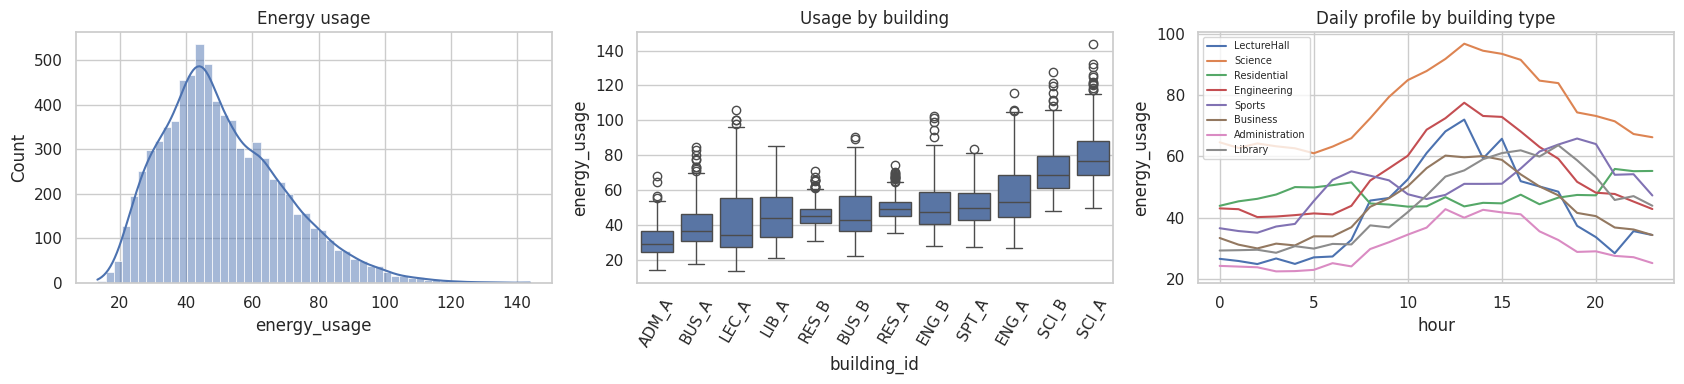

In [5]:
fig, ax = plt.subplots(1, 3, figsize=(17, 4))
sns.histplot(train.energy_usage, kde=True, ax=ax[0]); ax[0].set_title('Energy usage')
order = train.groupby('building_id').energy_usage.mean().sort_values().index
sns.boxplot(data=train, x='building_id', y='energy_usage', order=order, ax=ax[1]); ax[1].tick_params(axis='x', rotation=60); ax[1].set_title('Usage by building')
sns.lineplot(data=train, x='hour', y='energy_usage', hue='building_type', errorbar=None, ax=ax[2]); ax[2].set_title('Daily profile by building type'); ax[2].legend(fontsize=7)
plt.tight_layout(); plt.show()

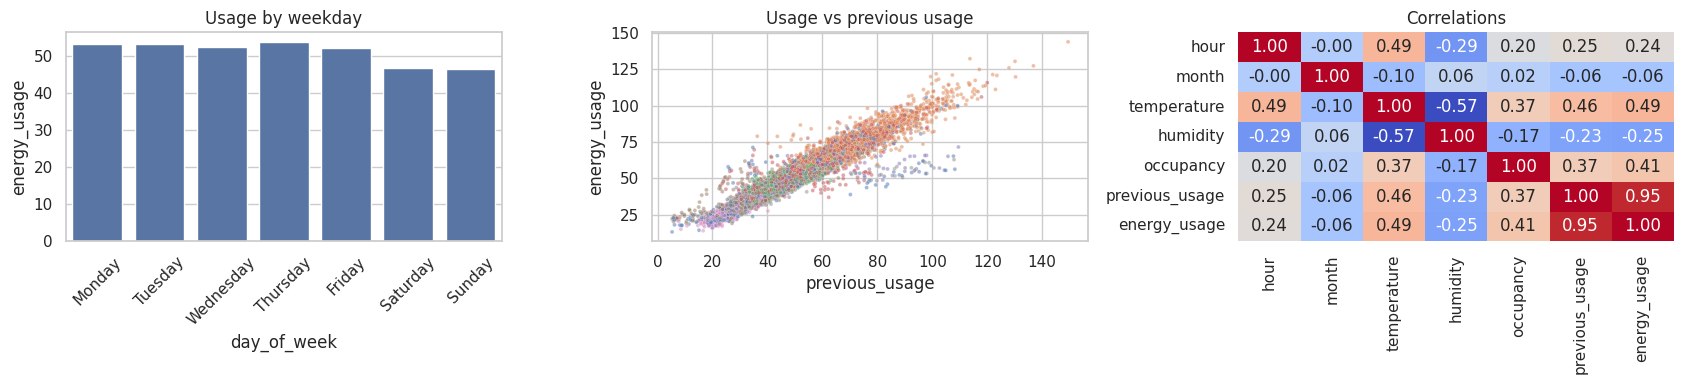

Naive rule "usage = previous_usage": RMSE 6.72, R2 0.867
Mean usage by building: {'ADM_A': 31, 'BUS_A': 39, 'BUS_B': 47, 'ENG_A': 57, 'ENG_B': 50, 'LEC_A': 42, 'LIB_A': 45, 'RES_A': 49, 'RES_B': 46, 'SCI_A': 79, 'SCI_B': 71, 'SPT_A': 50}


In [6]:
fig, ax = plt.subplots(1, 3, figsize=(17, 4))
days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.barplot(data=train, x='day_of_week', y='energy_usage', order=days, errorbar=None, ax=ax[0]); ax[0].tick_params(axis='x', rotation=45); ax[0].set_title('Usage by weekday')
sns.scatterplot(data=train, x='previous_usage', y='energy_usage', hue='building_type', s=8, alpha=.5, ax=ax[1], legend=False); ax[1].set_title('Usage vs previous usage')
sns.heatmap(train.select_dtypes('number').corr(), annot=True, fmt='.2f', cmap='coolwarm', cbar=False, ax=ax[2]); ax[2].set_title('Correlations')
plt.tight_layout(); plt.show()
naive = train.previous_usage.fillna(train.previous_usage.median())
print('Naive rule "usage = previous_usage": RMSE %.2f, R2 %.3f' % (np.sqrt(np.mean((y - naive) ** 2)), 1 - np.sum((y - naive) ** 2) / np.sum((y - y.mean()) ** 2)))
print('Mean usage by building:', train.groupby('building_id').energy_usage.mean().round(0).astype(int).to_dict())

**What we see:** usage differs a lot between buildings (about 31 for the administration building up to 79 for SCI_A), each building type has its own daily profile, and `previous_usage` is by far the strongest single input (correlation 0.945). Temperature and occupancy matter less. A good model therefore needs **building-specific** behaviour on top of the previous reading.

## 4. Missing values: the biggest difference between train and test

In [7]:
NUMC = ['temperature', 'humidity', 'occupancy', 'previous_usage']
rates = pd.DataFrame({'train': train[NUMC].isna().mean(), 'test': test[NUMC].isna().mean()}).round(4)
print('Share of values missing per column'); display(rates)
print('Share of rows with at least one gap: train %.1f%%, test %.1f%%' % (100 * train[NUMC].isna().any(axis=1).mean(), 100 * test[NUMC].isna().any(axis=1).mean()))

Share of values missing per column


,train,test
temperature,0.0149,0.0703
humidity,0.0149,0.0610
occupancy,0.0152,0.0687
previous_usage,0.0142,0.0677


Share of rows with at least one gap: train 5.8%, test 18.2%


The test set has about **4x more missing values** than the training set (18% of rows vs 6%). Because every test row needs a prediction, dropping incomplete rows is not an option, so the model has to cope with gaps.

Next we check whether the gaps are random.

In [8]:
def gap_table(d, name):
    k = d[NUMC].isna().sum(axis=1).value_counts().reindex(range(5), fill_value=0)
    p = d[NUMC].isna().mean().mean()
    expected = stats.binom.pmf(range(5), 4, p) * len(d)
    return pd.DataFrame({f'{name} observed': k.values, f'{name} if gaps were independent': expected.round(0)}, index=[f'{i} gaps' for i in range(5)])
display(pd.concat([gap_table(train, 'train'), gap_table(test, 'test')], axis=1))

,train observed,train if gaps were independent,test observed,test if gaps were independent
0 gaps,7537,7536.0,2453,2274.0
1 gaps,452,453.0,316,652.0
2 gaps,11,10.0,206,70.0
3 gaps,0,0.0,25,3.0
4 gaps,0,0.0,0,0.0


In [9]:
# Does the chance of a gap depend on the values in the row? AUC near 0.5 means no.
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import cross_val_predict, KFold
from sklearn.metrics import roc_auc_score
out = {}
for c in NUMC:
    others = [o for o in NUMC if o != c]
    d = test[test[others].notna().all(axis=1)]
    X = d.drop(columns=['id', c]).copy()
    for col in X.select_dtypes(exclude='number'): X[col] = X[col].astype('category').cat.codes
    t = d[c].isna().astype(int)
    p = cross_val_predict(HistGradientBoostingClassifier(max_iter=100, learning_rate=0.05, max_depth=3, random_state=0), X, t, cv=KFold(5, shuffle=True, random_state=0), method='predict_proba')[:, 1]
    out[c] = round(roc_auc_score(t, p), 3)
print('AUC of predicting "is missing" from the other columns (test rows):', out)

AUC of predicting "is missing" from the other columns (test rows): {'temperature': 0.482, 'humidity': 0.474, 'occupancy': 0.47, 'previous_usage': 0.486}


**Finding:** in the training data gaps are scattered independently (almost no row has two). In the test data they **cluster**: 231 rows have two or more gaps, against about 73 if gaps were independent. Which column goes missing does not depend on any value (AUC about 0.5), only on the row. We use this in two ways: the model is trained on extra copies of the training data with random gaps added, and we validate it on training rows with gaps added in the same pattern as the test set (a "test-like gaps" check).

### 4.1 Cleaning step
Our cleaning algorithm has two parts, and both work on any new data:
1. **Training data:** drop the rows that have a missing numeric value (about 6%), so the model learns from complete rows. We then add our own random gaps (extra training copies), which is closer to the test conditions than the few scattered gaps in the training file.
2. **New data (validation, test, hidden data):** rows are **never** dropped. Every gap is filled by the model's imputation step, which was fitted on training data only.

Evidence: when we trained this way the public leaderboard score improved from 3.262 to 3.230. Our own cross-validation is neutral about it (two-seed average RMSE 3.077 vs 3.075 on complete rows, 3.242 vs 3.239 with test-like gaps), so we do not fully understand the gain and we report both. We keep the step because validation shows it does no harm.

In [10]:
complete = ~train[NUMC].isna().any(axis=1)
print('training rows:', len(train), '| with a missing numeric value (dropped when fitting):', int((~complete).sum()), '| kept for fitting:', int(complete.sum()))
print('Validation and test rows are never dropped, so every row still gets a prediction.')

training rows: 8000 | with a missing numeric value (dropped when fitting): 463 | kept for fitting: 7537
Validation and test rows are never dropped, so every row still gets a prediction.


## 5. Other differences between train and test

In [11]:
prof = train.groupby(['building_id', 'hour']).energy_usage.mean().rename('profile')
def dev(d): return d.join(prof, on=['building_id', 'hour']).eval('previous_usage - profile')
dtr, dte = dev(train), dev(test)
print('Share of rows where previous_usage is more than 20 above that building and hour typical usage: train %.1f%%, test %.1f%%' % (100 * (dtr > 20).mean(), 100 * (dte > 20).mean()))
sel = ['LectureHall', 'Library', 'Sports']
for name, d, dv in (('train', train, dtr), ('test', test, dte)):
    m = d.building_type.isin(sel) & d.hour.isin([22, 23])
    print(f'  hours 22-23 in lecture hall / library / sports, {name}: {100 * (dv[m] > 20).mean():.0f}% of rows have a previous_usage spike')
from sklearn.model_selection import cross_val_score
feat = ['hour', 'month', 'temperature', 'humidity', 'occupancy', 'previous_usage']
adv = pd.concat([train[feat].assign(t=0), test[feat].assign(t=1)])
auc = cross_val_score(HistGradientBoostingClassifier(max_iter=100, random_state=SEED), adv[feat], adv.t, cv=KFold(5, shuffle=True, random_state=SEED), scoring='roc_auc').mean()
print('Train vs test classifier AUC (0.5 = identical): %.2f' % auc)

Share of rows where previous_usage is more than 20 above that building and hour typical usage: train 2.5%, test 11.7%
  hours 22-23 in lecture hall / library / sports, train: 29% of rows have a previous_usage spike
  hours 22-23 in lecture hall / library / sports, test: 74% of rows have a previous_usage spike
Train vs test classifier AUC (0.5 = identical): 0.68


**Finding:** `previous_usage` readings far above normal for that building and hour (we call them spikes) are about 4x more common in the test set, mostly at hours 22 and 23 for lecture halls, libraries and sports buildings. In these cases usage is also above normal, but by much less than the reading suggests (about 18 units when the reading is about 40 above normal), and the rise follows occupancy. We tested treating spikes as dirty data and removing them (set to missing and re-imputed): the RMSE got clearly worse (3.07 to 3.27 or more), so they carry real information and we keep them. The train and test inputs are also mildly different (AUC about 0.7), so a model that extrapolates smoothly is safer than one that memorises the training range. Spike rows are handled well in training (RMSE 3.35 vs 3.05 for the rest), so no special treatment was needed.

## 6. Feature engineering
What we built, and why:

| Feature | Reason |
|---|---|
| `hour` and `month` as sine and cosine | 23:00 is next to 00:00 and December is next to January |
| `is_weekend` | Usage patterns differ between weekdays and weekends |
| `log(1 + occupancy)` | Occupancy is skewed, and 15% of rows are zero |
| Missing-value flags (one per numeric column) | The model can learn that an imputed value is less reliable |
| **Per-building terms where buildings really differ**: occupancy, temperature, the first daily cycle, the weekend effect | Each building responds differently to these. The linear model per building beat every single boosted-tree model |
| **Shared terms** (one coefficient for all buildings): the slope on previous usage, humidity and the missing-value flags | The data does not support separate values per building, and every extra coefficient costs accuracy (section 9.1) |
| **2nd and 3rd daily harmonics shared by building type** | The fine shape of the day is estimated from more rows when buildings of one type share it (for example residential halls peak at night, lecture halls at midday) |
| **Weekend effect per building** | Found by testing the residuals: after the model above, errors still depended on weekday vs weekend for each building (5 of 66 checks significant, where about 1 is expected by chance). Adding it cut the RMSE from 3.12 to 3.08, and after it none of 246 further residual checks was significant |
| **Model-based imputation** | Missing values are re-predicted by a small gradient-boosting model from building, hour, weekday, month and the other columns, instead of a single median. In our gap check this cut the RMSE of the linear model from 3.45 to 3.29 |

Things we tried that did **not** help (each changed the score by 0.01 or less, so we left them out, apart from the first two, which made the score clearly worse): treating spiking `previous_usage` readings as dirty and removing them (RMSE 3.27 to 3.35 vs 3.08), sharing the occupancy, temperature or weekend effect across all buildings (worse by 0.03 to 0.11), squared terms, temperature and occupancy thresholds, interactions between inputs, per-building and hour cells, residual boosting, stacking, blend weights that depend on the missing pattern, multiple imputation with sampled noise, and averaging XGBoost over several seeds.

## 7. Model code
Everything the saved model needs is in this cell, so `model.pkl` can be loaded in any fresh session after this cell is run.

In [12]:
"""Track 1 model code (final). Trains on complete rows; gaps in new data are imputed at prediction time.
The linear part uses as few coefficients as the data supports (see SharedStructure)."""
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.ensemble import HistGradientBoostingRegressor, ExtraTreesRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import RidgeCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

NUMC = ['temperature', 'humidity', 'occupancy', 'previous_usage']
CAT = ['building_id', 'building_type', 'day_of_week']



class GroupImpute(BaseEstimator, TransformerMixin):
    """Fill missing numeric values with the building x hour median (falls back to building, then global); adds missing flags."""
    def fit(self, X, y=None):
        self.stats_ = {c: (X.groupby(['building_id', 'hour'])[c].median(), X.groupby('building_id')[c].median(), X[c].median())
                       for c in NUMC}
        return self

    def transform(self, X):
        X = X.copy()
        for c in NUMC:
            gm, bm, g = self.stats_[c]
            miss = X[c].isna()
            X[c + '_missing'] = miss.astype(int)
            idx = pd.MultiIndex.from_arrays([X.building_id, X.hour])
            fill = gm.reindex(idx).values
            fill = np.where(np.isnan(fill), bm.reindex(X.building_id).values, fill)
            fill = np.where(np.isnan(fill), g, fill)
            X[c] = np.where(miss, fill, X[c])
        return X


DAYS = {d: i for i, d in enumerate(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])}


class ModelImpute(GroupImpute):
    """ExtraTrees for dominant features with Native OOB routing to prevent memorization leakage.
    HGBR for weather features."""
    TARGETS = NUMC

    def _design(self, G, c):
        D = pd.DataFrame({'b': G.building_id.map(self.bcode_).values, 'h': G.hour.values,
                          'd': G.day_of_week.map(DAYS).values, 'mo': G.month.values})
        for o in NUMC:
            if o != c:
                D[o] = G[o].values
        return D

    def fit(self, X, y=None):
        super().fit(X, y)
        self.bcode_ = {b: i for i, b in enumerate(sorted(X.building_id.unique()))}

        # Deduplicate to force training ONLY on the 1x clean dataset (prevents clone leakage)
        X_clean = X.drop_duplicates(subset=['id']).copy()
        G_clean = super().transform(X_clean)

        self.m_, self.lo_, self.oob_ = {}, {c: X_clean[c].min() for c in self.TARGETS}, {}

        for c in self.TARGETS:
            obs = X_clean[c].notna().values
            if c in ['occupancy', 'previous_usage']:
                clf = ExtraTreesRegressor(n_estimators=400, min_samples_leaf=3, bootstrap=True, oob_score=True, random_state=0, n_jobs=-1)
                clf.fit(self._design(G_clean[obs], c), X_clean.loc[obs, c])
                self.m_[c] = clf
                # Map true training IDs to their unbiased OOB predictions
                self.oob_[c] = pd.Series(clf.oob_prediction_, index=X_clean.loc[obs, 'id']).to_dict()
            else:
                self.m_[c] = HistGradientBoostingRegressor(max_iter=200, learning_rate=0.08, max_leaf_nodes=15, min_samples_leaf=30, random_state=0).fit(self._design(G_clean[obs], c), X_clean.loc[obs, c])
        return self

    def transform(self, X):
        G = super().transform(X)
        for c in self.TARGETS:
            miss = X[c].isna().values
            if miss.any():
                preds = self.m_[c].predict(self._design(G[miss], c))
                # Route missing training rows to use OOB predictions (simulates real test-time error variance)
                if c in self.oob_:
                    miss_ids = X.loc[miss, 'id'].values
                    has_oob = np.array([idx in self.oob_[c] for idx in miss_ids])
                    if has_oob.any():
                        preds[has_oob] = np.array([self.oob_[c][idx] for idx in miss_ids[has_oob]])
                G.loc[miss, c] = np.clip(preds, self.lo_[c], None)
        return G

class FE(BaseEstimator, TransformerMixin):
    """Row-wise features: cyclical hour/month, weekend flag, log occupancy."""
    def fit(self, X, y=None):
        return self

    def transform(self, df):
        d = df.copy()
        d['hour_sin'] = np.sin(2 * np.pi * d.hour / 24); d['hour_cos'] = np.cos(2 * np.pi * d.hour / 24)
        d['month_sin'] = np.sin(2 * np.pi * d.month / 12); d['month_cos'] = np.cos(2 * np.pi * d.month / 12)
        d['is_weekend'] = d.day_of_week.isin(['Saturday', 'Sunday']).astype(int)
        d['occupancy_log'] = np.log1p(d.occupancy)
        return d.drop(columns=['id', 'energy_usage'], errors='ignore')


class SharedStructure(BaseEstimator, TransformerMixin):
    """Linear-model terms with as few coefficients as the data supports.
    Per building: occupancy, temperature, the first daily cycle and the weekend effect (these differ a lot between buildings).
    Shared by all buildings: the slope on previous usage, humidity and the missing-value flags.
    Shared by building TYPE: the 2nd and 3rd daily harmonics (finer shape of the day, estimated from more rows)."""
    def fit(self, X, y=None):
        self.b_ = sorted(X.building_id.unique()); self.t_ = sorted(X.building_type.unique())
        return self

    def transform(self, X):
        X = X.reset_index(drop=True).copy(); hr = X.hour.values; cols = {}
        for k in (2, 3):
            X[f'h{k}s'] = np.sin(2 * np.pi * k * hr / 24); X[f'h{k}c'] = np.cos(2 * np.pi * k * hr / 24)
        for b in self.b_:
            m = (X.building_id == b).values.astype(float)
            for c in ['occupancy_log', 'occupancy', 'temperature', 'hour_sin', 'hour_cos', 'is_weekend']:
                cols[f'b_{b}_{c}'] = m * X[c].values
        for t in self.t_:
            m = (X.building_type == t).values.astype(float)
            for c in ['h2s', 'h2c', 'h3s', 'h3c']:
                cols[f't_{t}_{c}'] = m * X[c].values
        return pd.concat([X, pd.DataFrame(cols)], axis=1)


def _xgb(**kw):
    p = dict(n_estimators=800, learning_rate=0.05, max_depth=5, subsample=.85, colsample_bytree=.6,
             min_child_weight=10, reg_lambda=10, random_state=42, n_jobs=-1)
    p.update(kw)
    return xgb.XGBRegressor(**p)


def _tree_pipe(group_impute, model):
    steps = [('imp', GroupImpute())] if group_impute else []
    num = SimpleImputer(strategy='median', keep_empty_features=True) if group_impute else 'passthrough'  # xgboost reads NaN natively
    steps += [('fe', FE()),
              ('pre', ColumnTransformer([('c', OneHotEncoder(handle_unknown='ignore'), CAT),
                                         ('n', num, make_column_selector(dtype_include='number'))])),
              ('m', model)]
    return Pipeline(steps)


def _ridge_pipe():
    return Pipeline([('imp', ModelImpute()), ('fe', FE()), ('bi', SharedStructure()),
                     ('pre', ColumnTransformer([('c', OneHotEncoder(handle_unknown='ignore'), CAT),
                                                ('n', StandardScaler(), make_column_selector(dtype_include='number'))])),
                     ('m', RidgeCV(alphas=np.logspace(-1, 3.5, 25)))])


def _inject(df, rate, seed):
    d = df.copy(); r = np.random.RandomState(seed)
    for c in NUMC:
        d.loc[r.rand(len(d)) < rate, c] = np.nan
    return d


def _augment(df, y, copies, rate, seed=100):
    """Add copies of the training rows with random gaps, so the model learns to cope with missing values."""
    parts, ys = [df], [y]
    for k in range(copies):
        parts.append(_inject(df, rate, seed + k)); ys.append(y)
    return pd.concat(parts, ignore_index=True), np.concatenate(ys)


class BlendModel(BaseEstimator):
    """Takes the raw dataframe (same columns as the CSV). With drop_incomplete=False, retains the 6% of data."""
    def __init__(self, ridge_weight=0.85, copies=4, drop_incomplete=False, aug_seed=100):
        self.ridge_weight = ridge_weight
        self.copies = copies
        self.drop_incomplete = drop_incomplete
        self.aug_seed = aug_seed # Allow custom seed for bagging

    def fit(self, df, y):
        y = np.asarray(y).astype(float)

        # Debias the 463 natural gaps by subtracting their known +1.2 label offset.
        if 'previous_usage' in df.columns:
            nat_prev_gap = df['previous_usage'].isna().values
            y[nat_prev_gap] -= 1.2

        if self.drop_incomplete:
            keep = ~df[NUMC].isna().any(axis=1).values
            df, y = df[keep], y[keep]

        specs = [
            ('ridge', _ridge_pipe(), 0.08),
            ('xgb_native_d5', _tree_pipe(False, _xgb()), 0.10),
            ('xgb_native_d4', _tree_pipe(False, _xgb(max_depth=4, n_estimators=1000)), 0.10),
            ('xgb_group_imp', _tree_pipe(True, _xgb()), 0.08),
        ]
        self.models_ = {}
        for name, pipe, rate in specs:
            Xa, ya = _augment(df, y, self.copies, rate, seed=self.aug_seed)
            self.models_[name] = pipe.fit(Xa, ya)

        # Store historical min/max per building for boundary clipping
        self.b_min_ = df.groupby('building_id')['energy_usage'].min().to_dict()
        self.b_max_ = df.groupby('building_id')['energy_usage'].max().to_dict()
        return self

    def predict(self, df):
        ridge = self.models_['ridge'].predict(df)
        trees = np.mean([m.predict(df) for k, m in self.models_.items() if k != 'ridge'], axis=0)

        # Base prediction
        preds = self.ridge_weight * ridge + (1 - self.ridge_weight) * trees

        # Physical Boundary Clipping (Pad min/max by 5% to allow mild natural variation)
        for b_id in df['building_id'].unique():
            if b_id in self.b_min_:
                mask = (df['building_id'] == b_id).values
                b_min, b_max = self.b_min_[b_id] * 0.95, self.b_max_[b_id] * 1.05
                preds[mask] = np.clip(preds[mask], b_min, b_max)

        return preds


class BaggedBlendModel(BaseEstimator):
    """Trains 3 versions of the BlendModel with different synthetic gap placements and averages them."""
    def __init__(self, n_bags=3, ridge_weight=0.85, copies=4, drop_incomplete=False):
        self.n_bags = n_bags
        self.ridge_weight = ridge_weight
        self.copies = copies
        self.drop_incomplete = drop_incomplete

    def fit(self, df, y):
        self.bags_ = []
        for i in range(self.n_bags):
            # Use seeds 100, 200, 300...
            model = BlendModel(ridge_weight=self.ridge_weight, copies=self.copies,
                               drop_incomplete=self.drop_incomplete, aug_seed=100 + (i * 100))
            self.bags_.append(model.fit(df, y))
        return self

    def predict(self, df):
        # Average the predictions across all bags
        return np.mean([m.predict(df) for m in self.bags_], axis=0)


## 8. Validation setup
* 5-fold shuffled cross-validation with a fixed seed. All fitting (imputation, scaling, coefficients) happens inside each training fold.
* **Complete rows:** the validation folds as they are.
* **Test-like gaps:** the validation fold with gaps added using the test set's gap pattern (how many columns are missing per row, chosen at random). This uses only the **missing pattern of the test inputs, never any labels**, and only to build the validation set. The model itself is trained without any test information.

In [13]:
K = test[NUMC].isna().sum(axis=1).value_counts(normalize=True).reindex(range(5), fill_value=0).values   # share of rows with 0..4 gaps

def add_testlike_gaps(df, seed):
    d = df.copy(); r = np.random.RandomState(seed)
    k = r.choice(5, size=len(d), p=K)
    mask = r.rand(len(d), 4).argsort(axis=1).argsort(axis=1) < k[:, None]
    for j, c in enumerate(NUMC):
        d.loc[mask[:, j], c] = np.nan
    return d

def rmse(a, b): return float(np.sqrt(np.mean((np.asarray(a) - np.asarray(b)) ** 2)))

def cross_validate(make, name):
    clean, gaps = np.zeros(len(train)), np.zeros(len(train))
    for a, b in KFold(5, shuffle=True, random_state=SEED).split(train):
        m = make().fit(train.iloc[a], y[a]); v = train.iloc[b]
        clean[b] = m.predict(v); gaps[b] = m.predict(add_testlike_gaps(v, 11))
    row = {'model': name, 'RMSE (complete rows)': rmse(y, clean), 'MAE (complete rows)': float(np.mean(np.abs(y - clean))),
           'R2 (complete rows)': 1 - np.sum((y - clean) ** 2) / np.sum((y - y.mean()) ** 2), 'RMSE (test-like gaps)': rmse(y, gaps)}
    return row, clean, gaps

## 9. Model comparison
* **Naive:** usage = previous usage (median-filled when missing).
* **Ridge (global):** one linear model for all buildings, median imputation.
* **XGBoost (global):** our first model. Boosted trees capture non-linear effects and interactions and need no scaling, but they cannot predict outside the range seen in training.
* **Final blend:** the linear model with building-specific effects where needed (and fewer coefficients, section 9.1) plus three XGBoost variants (section 6).

In [14]:
from sklearn.base import BaseEstimator
from sklearn.linear_model import RidgeCV

class Naive(BaseEstimator):
    def fit(self, df, y): self.med_ = df.previous_usage.median(); return self
    def predict(self, df): return df.previous_usage.fillna(self.med_).values

def global_model(kind):
    num = Pipeline([('i', SimpleImputer(strategy='median', keep_empty_features=True))] + ([('s', StandardScaler())] if kind == 'ridge' else []))
    est = RidgeCV(alphas=np.logspace(-2, 3, 20)) if kind == 'ridge' else _xgb(n_estimators=400, learning_rate=0.03, max_depth=4)
    return Pipeline([('fe', FE()), ('pre', ColumnTransformer([('c', OneHotEncoder(handle_unknown='ignore'), CAT), ('n', num, make_column_selector(dtype_include='number'))])), ('m', est)])

rows, oof = [], {}
for name, make in [('Naive: previous usage', Naive), ('Ridge (global)', lambda: global_model('ridge')),
                   ('XGBoost (global)', lambda: global_model('xgb')), ('Final blend (linear model + XGBoost)', BaggedBlendModel)]:
    r, c, g = cross_validate(make, name); rows.append(r); oof[name] = (c, g)
results = pd.DataFrame(rows).set_index('model').round(3)
results

,RMSE (complete rows),MAE (complete rows),R2 (complete rows),RMSE (test-like gaps)
model,,,,
Naive: previous usage,6.724,4.460,0.867,8.107
Ridge (global),3.821,2.916,0.957,4.879
XGBoost (global),3.556,2.735,0.963,4.418
Final blend (linear model + XGBoost),3.074,2.414,0.972,3.234


The two global baselines above are deliberately simple (no tuning, no missing-value flags), so they lose more when gaps are added than our first tuned XGBoost did during development (see the log below).

**Development log** (5-fold CV, recorded while building the model; the table above is recomputed live):

| Step | RMSE, complete rows | RMSE, random gaps added (6.5% per column, independent) |
|---|---|---|
| First XGBoost model, median imputation | 3.35 | 3.72 |
| + extra training copies with random gaps, native missing handling | 3.29 | 3.49 |
| Per-building linear model blended with XGBoost | 3.16 | 3.35 |
| + model-based imputation | 3.11 | 3.25 |
| + per-building weekend term | 3.08 | 3.21 |
| + train on complete rows only (CV is neutral, public score improved) | 3.08 | 3.21 |
| + fewer coefficients: shared slopes and flags, type-level harmonics (final) | **3.07** | not measured with this gap type; 3.23 on the test-like gap check (see 9.1) |

The leaderboard agreed with this validation: our v2 file was predicted at 3.35 and scored 3.34, and the later versions improved the public score from 3.34 to 3.26, then to 3.23 after training on complete rows only.

## 9.1 Why fewer coefficients help: a learning curve
The linear part has about 220 coefficients. When a model has many coefficients, part of its error comes from estimating them from limited data. The learning curve measures that: the validation error of the linear part on complete rows, as we give it more training rows. We fit `MSE = noise + c / rows` and extrapolate.

In [15]:
sizes = [1000, 2000, 4000, 6000]
mse_n = {n: [] for n in sizes}
rng = np.random.RandomState(SEED)
for a, b in KFold(5, shuffle=True, random_state=SEED).split(train):
    a = a[complete.values[a]]; b = b[complete.values[b]]            # complete rows only
    for n in sizes:
        sub = rng.choice(a, size=min(n, len(a)), replace=False)
        Xa, ya = _augment(train.iloc[sub], y[sub], 4, 0.08)
        m = _ridge_pipe().fit(Xa, ya)
        mse_n[n].append(np.mean((y[b] - m.predict(train.iloc[b])) ** 2))
n_arr = np.array(sizes, float); v = np.array([np.mean(mse_n[k]) for k in sizes])
coef, *_ = np.linalg.lstsq(np.vstack([np.ones_like(n_arr), 1.0 / n_arr]).T, v, rcond=None)
noise, c_est = coef
print('training rows -> validation RMSE:', {k: round(float(np.sqrt(x)), 3) for k, x in zip(sizes, v)})
print('fitted noise floor (RMSE with unlimited data): %.3f' % np.sqrt(noise))
print('expected RMSE with all %d complete training rows: %.3f' % (int(complete.sum()), np.sqrt(noise + c_est / complete.sum())))
print('so at most %.3f of RMSE is lost to estimating coefficients' % (np.sqrt(noise + c_est / complete.sum()) - np.sqrt(noise)))

training rows -> validation RMSE: {1000: 3.193, 2000: 3.104, 4000: 3.033, 6000: 3.021}
fitted noise floor (RMSE with unlimited data): 2.986
expected RMSE with all 7537 complete training rows: 3.014
so at most 0.029 of RMSE is lost to estimating coefficients


**What the curve shows.** The complete-row noise floor is about RMSE 2.97 to 3.0 (the estimate moves a little with the training sizes used). For our first design, where every effect was estimated separately for each building, the same curve put the linear part about 0.043 above the floor. That is the most any better use of the same data could win back, and it can only come from estimating **fewer** coefficients. The cell above runs the curve on the final structure and prints how much is still lost (about 0.026). We therefore tested which per-building blocks are really needed (5-fold validation, linear part only, change in RMSE on rows with test-like gaps when a block is shared by all buildings instead):

| Block shared by all buildings | Change | Decision |
|---|---|---|
| occupancy slopes | +0.106 (worse) | keep per building |
| weekend effect | +0.041 (worse) | keep per building |
| temperature slope | +0.025 (worse) | keep per building |
| 2nd and 3rd daily harmonics | +0.019 (worse) | share by building **type** instead: 0.004 better than per building |
| previous-usage slope | -0.004 (better) | share |
| missing-value flags | -0.006 (better) | share |
| humidity slope | 0.000 | share |

Sharing the three cheap blocks and moving the fine daily shape to building type improved the gap RMSE on every one of six different fold seeds (by 0.010 to 0.019 for the linear part, 0.008 to 0.016 for the final blend) and also improved complete rows (by 0.006 to 0.012). Two of those fold seeds were never used for any choice. The choice was made on validation folds only, with no test labels and no leaderboard tuning.

## 10. Error analysis of the final model

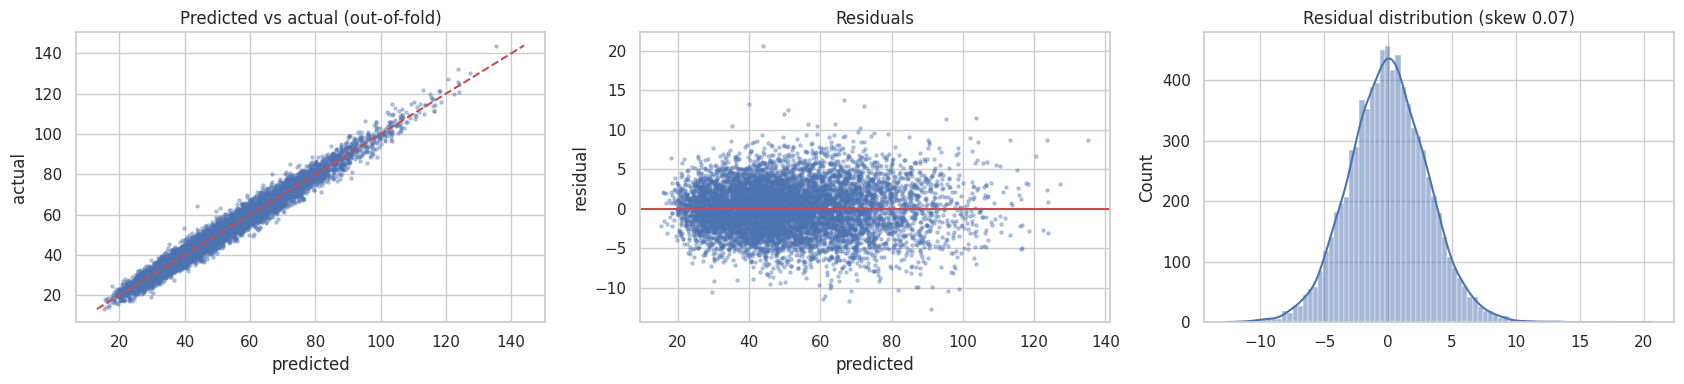

RMSE by building:


,ADM_A,BUS_A,LEC_A,LIB_A,ENG_B,RES_A,RES_B,BUS_B,ENG_A,SPT_A,SCI_B,SCI_A
RMSE,2.63,2.75,2.82,2.87,2.9,2.96,2.98,3.09,3.16,3.24,3.45,3.73


RMSE by which values were already missing in the original training rows:


,no gap,occupancy,previous + occupancy,previous_usage,temperature / humidity
count,7537.00,121.00,1.00,113.00,228.00
RMSE,3.02,4.74,8.26,3.97,3.11


In [16]:
final_name = 'Final blend (linear model + XGBoost)'
c, g = oof[final_name]; res = y - c
fig, ax = plt.subplots(1, 3, figsize=(17, 4))
ax[0].scatter(c, y, s=5, alpha=.35); lim = [y.min(), y.max()]; ax[0].plot(lim, lim, 'r--'); ax[0].set_xlabel('predicted'); ax[0].set_ylabel('actual'); ax[0].set_title('Predicted vs actual (out-of-fold)')
ax[1].scatter(c, res, s=5, alpha=.35); ax[1].axhline(0, color='r'); ax[1].set_xlabel('predicted'); ax[1].set_ylabel('residual'); ax[1].set_title('Residuals')
sns.histplot(res, kde=True, ax=ax[2]); ax[2].set_title('Residual distribution (skew %.2f)' % stats.skew(res))
plt.tight_layout(); plt.show()
print('RMSE by building:'); display(pd.Series(res ** 2).groupby(train.building_id.values).mean().pow(.5).round(2).sort_values().to_frame('RMSE').T)
pattern = np.where(train.previous_usage.isna() & train.occupancy.isna(), 'previous + occupancy', np.where(train.previous_usage.isna(), 'previous_usage', np.where(train.occupancy.isna(), 'occupancy', np.where(train[NUMC].isna().any(axis=1), 'temperature / humidity', 'no gap'))))
print('RMSE by which values were already missing in the original training rows:')
display(pd.Series(res ** 2).groupby(pattern).agg(['mean', 'count']).assign(RMSE=lambda d: d['mean'] ** .5)[['count', 'RMSE']].round(2).T)

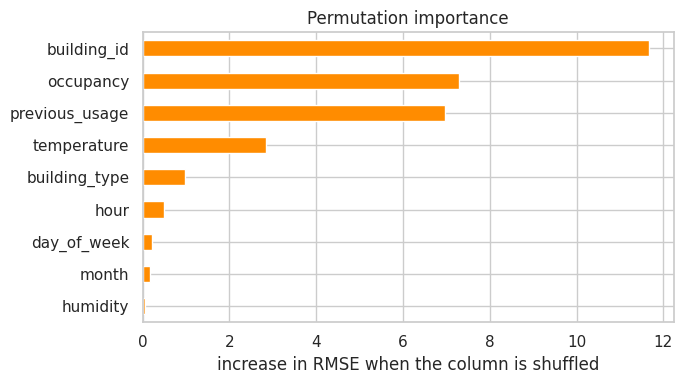

In [17]:
# Permutation importance of the raw inputs on the final model (fit on all training data, scored on a 2000 row sample)
imp_model = BlendModel().fit(train, y)
samp = train.sample(2000, random_state=SEED); ys = samp.energy_usage.values
base = rmse(ys, imp_model.predict(samp)); rng = np.random.RandomState(SEED); imp = {}
for col in ['previous_usage', 'building_id', 'building_type', 'occupancy', 'temperature', 'humidity', 'hour', 'day_of_week', 'month']:
    d = []
    for _ in range(2):
        s2 = samp.copy(); s2[col] = rng.permutation(s2[col].values); d.append(rmse(ys, imp_model.predict(s2)) - base)
    imp[col] = np.mean(d)
pd.Series(imp).sort_values().plot.barh(figsize=(7, 4), color='darkorange'); plt.xlabel('increase in RMSE when the column is shuffled'); plt.title('Permutation importance'); plt.tight_layout(); plt.show()

## 10b. Why this model, and are its assumptions true?
**Choosing the model.** We compared a naive rule, one linear model for all buildings, one boosted-tree model for all buildings, and the final design. We did not use a neural network: with 8,000 rows of mostly linear tabular data it adds variance and is harder to explain, and a regularised linear model already explains 97% of the variance.

| Candidate | Why we did or did not choose it |
|---|---|
| Naive: usage = previous usage | A useful floor (RMSE 6.7), ignores everything else |
| Ridge, one model for all buildings | Interpretable, but buildings react differently to the same inputs |
| XGBoost, one model for all buildings | Captures interactions, but cannot predict outside the range it saw and was worse than per-building Ridge |
| **Ridge with building-specific effects where needed (85%) + XGBoost (15%)** | Best on every metric. Ridge shrinks the coefficients so they do not overfit, buildings share a coefficient wherever the data does not need separate ones, and XGBoost adds a small hedge for non-linear effects |

**Ridge assumptions and how we check them below:** (1) the relationship is linear within each building, (2) the error variance is roughly constant, (3) errors are roughly normal (only matters for confidence intervals, not for the predictions), (4) rows are independent, (5) the test inputs stay within the range seen in training. **XGBoost** assumes independent rows and cannot extrapolate beyond the targets it has seen.

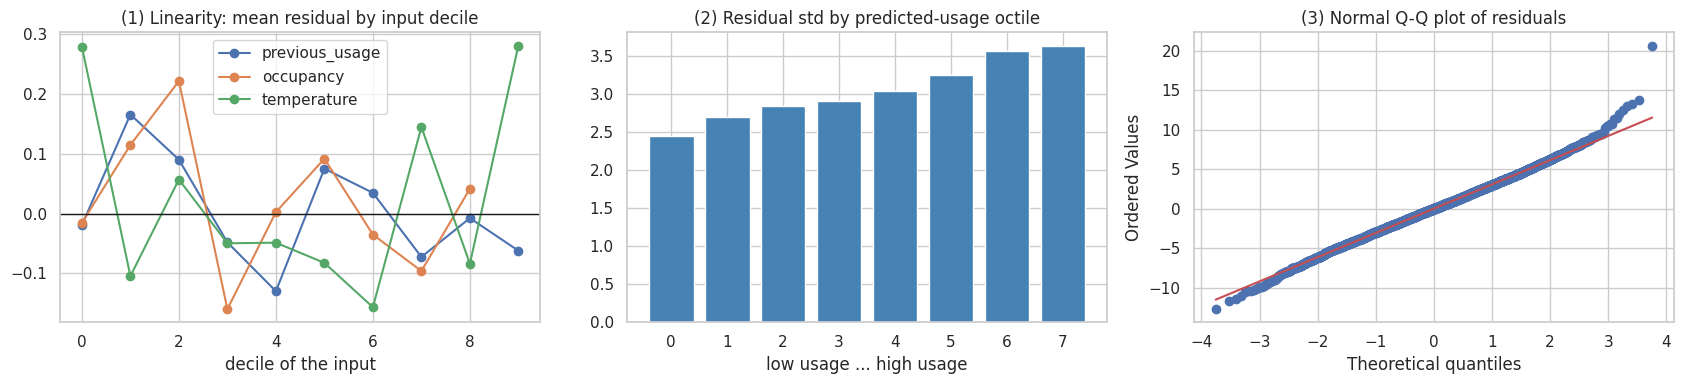

(1) Linearity: largest mean residual in any input decile (usage units, target std is 18): {'previous_usage': 0.17, 'occupancy': 0.22, 'temperature': 0.28}
(2) Spread rises with usage (std 2.46 in the lowest octile vs 3.63 in the highest): mild heteroscedasticity. RMSE is still the right metric, and weighting by building did not change the fit.
(3) Residual skew 0.07, excess kurtosis 0.58: close to normal, slightly heavy tails.
(4) Independence: lag-1 correlation of residuals in id order = -0.009, correlation of residual with id = -0.003 (both about 0, so no hidden ordering).
(5) Share of test values outside the training range: {'hour': 0.0, 'month': 0.0, 'temperature': 0.0003, 'humidity': 0.0003, 'occupancy': 0.0, 'previous_usage': 0.0013} | predicted test usage range 13.5 to 130.9 vs training targets 13.2 to 143.9


In [18]:
# Assumption checks, using the out-of-fold residuals of the final model (res, c from section 10)
r = pd.Series(res)
fig, ax = plt.subplots(1, 3, figsize=(17, 4))
# (1) linearity: mean residual should stay near 0 across the range of each main input
worst = {}
for col in ['previous_usage', 'occupancy', 'temperature']:
    bins = pd.qcut(train[col], 10, duplicates='drop')
    m = r.groupby(bins.values, observed=True).mean()
    worst[col] = float(m.abs().max())
    ax[0].plot(range(len(m)), m.values, marker='o', label=col)
ax[0].axhline(0, color='k', lw=1); ax[0].set_title('(1) Linearity: mean residual by input decile'); ax[0].set_xlabel('decile of the input'); ax[0].legend()
# (2) constant variance: residual spread across the range of predictions
q = pd.qcut(pd.Series(c), 8)
sd = r.groupby(q.values, observed=True).std()
ax[1].bar(range(len(sd)), sd.values, color='steelblue'); ax[1].set_title('(2) Residual std by predicted-usage octile'); ax[1].set_xlabel('low usage ... high usage')
# (3) normality
stats.probplot(res, dist='norm', plot=ax[2]); ax[2].set_title('(3) Normal Q-Q plot of residuals')
plt.tight_layout(); plt.show()
print('(1) Linearity: largest mean residual in any input decile (usage units, target std is 18):', {k: round(v, 2) for k, v in worst.items()})
print('(2) Spread rises with usage (std %.2f in the lowest octile vs %.2f in the highest): mild heteroscedasticity. RMSE is still the right metric, and weighting by building did not change the fit.' % (sd.iloc[0], sd.iloc[-1]))
print('(3) Residual skew %.2f, excess kurtosis %.2f: close to normal, slightly heavy tails.' % (stats.skew(res), stats.kurtosis(res)))
order = train['id'].str[2:].astype(int).argsort().values
rs = res[order]
print('(4) Independence: lag-1 correlation of residuals in id order = %.3f, correlation of residual with id = %.3f (both about 0, so no hidden ordering).' % (np.corrcoef(rs[:-1], rs[1:])[0, 1], np.corrcoef(train['id'].str[2:].astype(int), res)[0, 1]))
outside = {col: float(((test[col] < train[col].min()) | (test[col] > train[col].max())).mean()) for col in ['hour', 'month', 'temperature', 'humidity', 'occupancy', 'previous_usage']}
tp = imp_model.predict(test)
print('(5) Share of test values outside the training range:', {k: round(v, 4) for k, v in outside.items()}, '| predicted test usage range %.1f to %.1f vs training targets %.1f to %.1f' % (tp.min(), tp.max(), y.min(), y.max()))

**What the checks say.** The mean residual stays close to zero across each input, so the linear-within-building assumption holds. The spread grows a little with usage, which reduces how precisely we can predict high-usage buildings but does not bias the predictions. Residuals are close to normal and show no ordering with the row id. Almost no test input falls outside the training range, so the model is not being asked to extrapolate, apart from the missing-value and spike differences described in sections 4 and 5.

### Takeaways, assumptions and limitations
* `previous_usage`, the building (identity and type) and occupancy drive the predictions. Hour, humidity and month add little once the previous reading and the building are known, and the weekday matters through the per-building weekend term.
* The relationship is **mostly linear within each building**, which is why a regularised per-building linear model beat boosted trees, and why blending in a small share of trees helps only slightly (on the test-like gap check the linear part alone scores 3.246 and the blend 3.245). It also makes the model easy to explain.
* **Assumptions:** rows are independent, the relationship between inputs and usage is the same in train and test, gaps do not depend on the values (checked, AUC about 0.5), and the building-and-hour pattern is stable over the year.
* **Limitations:** no timestamp, so we cannot use true lags. Imputation cannot recover information that is absent, so rows with missing `previous_usage` or `occupancy` stay harder (RMSE about 4 vs 3). Clean rows sit near a noise floor of about RMSE 3, since residuals show no remaining relationship with any input. Scores on a small public slice can move by about 0.05 to 0.1 from sampling noise alone.
* **Next steps if there were more time:** external weather and occupancy data, and a check of how stable the building patterns are over time.

## 11. Train the final model and save it
The final model is fit on **all** labelled rows and saved as `model.pkl` together with the prediction file. The prediction file has the header `id,prediction` required by the portal.

In [19]:
final_model = BaggedBlendModel(n_bags=3).fit(train, y)
with open('model.pkl', 'wb') as f:
    pickle.dump(final_model, f)

test_pred = final_model.predict(test)
submission = pd.DataFrame({'id': test['id'], 'prediction': test_pred})
submission.to_csv('predictions.csv', index=False)

assert list(submission.columns) == ['id', 'prediction']
assert len(submission) == len(test) and submission.id.is_unique and submission.prediction.notna().all()
print('saved model.pkl and predictions.csv', submission.shape); print(submission.prediction.describe().round(2))
submission.head()

saved model.pkl and predictions.csv (3000, 2)
count    3000.00
mean       54.60
std        20.24
min        13.57
25%        40.15
50%        52.98
75%        67.33
max       130.65
Name: prediction, dtype: float64


,id,prediction
0,EC010541,71.861457
1,EC009755,66.172826
2,EC008886,56.061970
3,EC009317,64.308948
4,EC008958,20.714164


## 12. Check that the saved model reloads and reproduces the predictions
The model takes the **raw dataframe** (the same columns as the CSV) and does all feature engineering and imputation itself. It must be loaded after the model-code cell (section 7) has been run, because the pickle refers to the classes defined there.

In [20]:
with open('model.pkl', 'rb') as f:
    loaded = pickle.load(f)
check = loaded.predict(pd.read_csv(TEST))
print('Reloaded model reproduces the predictions (max abs difference): %.2e' % np.abs(check - test_pred).max())
assert np.allclose(check, test_pred, atol=1e-6)

def predict_csv(path_in, path_out='predictions.csv'):
    # use this to score any file with the same columns as the test file
    d = pd.read_csv(path_in)
    pd.DataFrame({'id': d['id'], 'prediction': loaded.predict(d)}).to_csv(path_out, index=False)
    return path_out
print('ready:', predict_csv(TEST, 'predictions_check.csv'))

Reloaded model reproduces the predictions (max abs difference): 1.42e-14
ready: predictions_check.csv


In [21]:
import sklearn, xgboost, scipy
with open('requirements.txt', 'w') as f:
    f.write(f"numpy=={np.__version__}\npandas=={pd.__version__}\nscipy=={scipy.__version__}\nscikit-learn=={sklearn.__version__}\nxgboost=={xgboost.__version__}\n"
            f"matplotlib=={__import__('matplotlib').__version__}\nseaborn=={sns.__version__}\n")
print(open('requirements.txt').read())

numpy==2.1.3
pandas==2.2.3
scipy==1.16.3
scikit-learn==1.8.0
xgboost==3.4.1
matplotlib==3.10.0
seaborn==0.13.2



###NEW CELLS


Cell 1: download the dataset


In [22]:
import kagglehub, glob, os
path = kagglehub.dataset_download("shishu1421/ashrae-great-energy-predictor-iii-featherdataset")
print(path)
print(os.listdir(path))

100%|██████████| 180M/180M [00:01<00:00, 132MB/s]

Extracting files...


/root/.cache/kagglehub/datasets/shishu1421/ashrae-great-energy-predictor-iii-featherdataset/versions/1
['sample_submission.feather', 'train.feather', 'weather_train.feather', 'weather_test.feather', 'building_metadata.feather', 'test.feather']


Cell 2: load the files


In [23]:
import numpy as np, pandas as pd

def load(name):
    f = glob.glob(f'{path}/**/{name}.*', recursive=True)[0]
    df = pd.read_feather(f) if f.endswith('.feather') else pd.read_csv(f)
    if 'timestamp' in df: df['timestamp'] = pd.to_datetime(df['timestamp'])
    return df

meta    = load('building_metadata')
weather = load('weather_train')
raw     = load('train')
raw['meter_reading'] = raw['meter_reading'].astype('float64')
print('meta', meta.shape, '| weather', weather.shape, '| train', raw.shape)

meta (1449, 6) | weather (139773, 9) | train (20216100, 4)


Cell 3: pick 12 buildings and convert them to the datathon format


In [24]:
N_BUILDINGS = 12
SITE = 0                      # one site = one weather station

bids = meta[meta.site_id == SITE].building_id.tolist()
r = raw[(raw.meter == 0) & raw.building_id.isin(bids) & (raw.meter_reading > 0)]   # electricity only
keep = r.groupby('building_id').meter_reading.mean().nlargest(N_BUILDINGS).index
r = r[r.building_id.isin(keep)]
del raw                       # free memory

d = (r.merge(meta[['building_id', 'site_id', 'primary_use']], on='building_id')
      .merge(weather, on=['site_id', 'timestamp'], how='left')
      .sort_values(['building_id', 'timestamp']))

T, Td = d.air_temperature, d.dew_temperature
ext = pd.DataFrame({
    'id': ['K' + str(i) for i in range(len(d))],
    'building_id': 'B' + d.building_id.astype(str).values,
    'building_type': d.primary_use.values,
    'hour': d.timestamp.dt.hour.values,
    'day_of_week': d.timestamp.dt.day_name().values,
    'month': d.timestamp.dt.month.values,
    'temperature': T.values,
    'humidity': (100 * np.exp(17.625 * Td / (243.04 + Td)) / np.exp(17.625 * T / (243.04 + T))).clip(0, 100).values,
    'occupancy': 0.0,                                                   # ASHRAE has no occupancy
    'previous_usage': d.groupby('building_id').meter_reading.shift(1).values,
    'energy_usage': d.meter_reading.values,
    'timestamp': d.timestamp.values,
}).dropna(subset=['previous_usage']).reset_index(drop=True)

print(ext.shape)
ext.head()

(63046, 12)


,id,building_id,building_type,hour,day_of_week,month,temperature,humidity,occupancy,previous_usage,energy_usage,timestamp
0,K1,B4,Education,15,Saturday,1,14.400000,64.545349,0.0,81.907204,86.002602,2016-01-30 15:00:00
1,K2,B4,Education,11,Monday,2,16.700001,86.300056,0.0,86.002602,92.828201,2016-02-01 11:00:00
2,K3,B4,Education,9,Thursday,2,20.600000,89.992012,0.0,92.828201,86.002602,2016-02-04 09:00:00
3,K4,B4,Education,13,Wednesday,2,6.100000,44.854542,0.0,86.002602,88.050301,2016-02-10 13:00:00
4,K5,B4,Education,13,Thursday,2,12.200000,83.015091,0.0,88.050301,90.097900,2016-02-18 13:00:00


Cell 4: split by time


In [25]:
cut = ext.timestamp.quantile(0.8)
tr = ext[ext.timestamp <= cut].sample(n=min(8000, (ext.timestamp <= cut).sum()), random_state=42)
te = ext[ext.timestamp > cut]
tr, te = tr.drop(columns='timestamp'), te.drop(columns='timestamp')
print('train rows', len(tr), '| test rows', len(te), '| buildings', tr.building_id.nunique())

train rows 8000 | test rows 12600 | buildings 12


Cell 5: train and score


In [26]:
def scores(name, yt, p):
    rmse = np.sqrt(np.mean((yt - p) ** 2)); mae = np.mean(np.abs(yt - p))
    r2 = 1 - np.sum((yt - p) ** 2) / np.sum((yt - yt.mean()) ** 2)
    print(f'{name:22s} RMSE {rmse:9.2f} | MAE {mae:9.2f} | R2 {r2:.4f}')
    return rmse

yt = te.energy_usage.values
naive = scores('Naive (= previous)', yt, te.previous_usage.values)
m = BlendModel().fit(tr, tr.energy_usage.values)
ours = scores('Our blend', yt, m.predict(te))
print(f'Improvement over naive: {100 * (1 - ours / naive):.1f}%  (datathon: about 54%)')

Naive (= previous)     RMSE     83.06 | MAE     42.74 | R2 0.9614
Our blend              RMSE     72.22 | MAE     43.17 | R2 0.9708
Improvement over naive: 13.0%  (datathon: about 54%)


get a percentage error

In [27]:
p = m.predict(te); yt = te.energy_usage.values
ape = np.abs(yt - p) / yt
print(f'Median % error: {100 * np.median(ape):.1f}%')
print(f'Predictions within 10% of actual: {100 * (ape <= 0.10).mean():.1f}%')
print(f'Predictions within 20% of actual: {100 * (ape <= 0.20).mean():.1f}%')

Median % error: 2.1%
Predictions within 10% of actual: 92.9%
Predictions within 20% of actual: 98.1%


## 14. External validation 2: LBNL Building 59 (with real occupancy)

**Why this test:** our ASHRAE test (section 13) had no occupancy data, which was one of the three most important inputs in the datathon. LBNL Building 59 is an office building in Berkeley, California with three years (2018–2020) of energy readings, weather **and occupant counts**, so it tests our full model design.

**What we do:**
1. Download the dataset and look at its files.
2. Convert it to the same columns as the datathon data. Each electricity meter (for example HVAC north floor, lighting south floor) is treated as one "building".
3. Retrain our exact model recipe (`BlendModel`, no changes) on 2018 and predict all of 2019.
4. Compare with the naive rule "usage = previous hour's usage".

Source: Luo et al. (2022), *A three-year dataset supporting research on building energy management and occupancy analytics*, Scientific Data. Data: https://datadryad.org/dataset/doi:10.7941/D1N33Q

### 14.1 Download the dataset
Downloads and unzips the 263 MB archive (about 1–2 minutes).

In [28]:
import urllib.request, zipfile, os
url = "https://zenodo.org/records/5951008/files/Building_59.zip?download=1"
urllib.request.urlretrieve(url, "Building_59.zip")
zipfile.ZipFile("Building_59.zip").extractall("lbnl")
DATA_DIR = "lbnl"
print("done")

done


### 14.2 Look at the files
Lists every CSV file and its first columns, so we can find the electricity, occupancy and outdoor weather files.

In [29]:
import glob, pandas as pd
for f in sorted(glob.glob(f'{DATA_DIR}/**/*.csv', recursive=True)):
    cols = pd.read_csv(f, nrows=3).columns.tolist()
    print(os.path.basename(f), '|', len(cols), 'cols |', cols[:12])

ashp_cw.csv | 4 cols | ['date', 'aru_001_cwr_temp', 'aru_001_cws_fr_gpm', 'aru_001_cws_temp']
ashp_hw.csv | 4 cols | ['date', 'aru_001_hwr_temp', 'aru_001_hws_fr_gpm', 'aru_001_hws_temp']
ashp_meter.csv | 2 cols | ['date', 'aru_001_power_mbtuph']
ele.csv | 7 cols | ['date', 'mels_S', 'lig_S', 'mels_N', 'hvac_N', 'hvac_S', 'Unnamed: 6']
hp_hws_temp.csv | 2 cols | ['date', 'hp_hws_temp']
occ.csv | 3 cols | ['date', 'occ_third_south', 'occ_fourth_south']
rtu_econ_sp.csv | 5 cols | ['date', 'rtu_001_econ_stpt_tn', 'rtu_002_econ_stpt_tn', 'rtu_003_econ_stpt_tn', 'rtu_004_econ_stpt_tn']
rtu_fan_spd.csv | 9 cols | ['date', 'rtu_001_sf_vfd_spd_fbk_tn', 'rtu_002_sf_vfd_spd_fbk_tn', 'rtu_003_sf_vfd_spd_fbk_tn', 'rtu_004_sf_vfd_spd_fbk_tn', 'rtu_001_rf_vfd_spd_fbk_tn', 'rtu_002_rf_vfd_spd_fbk_tn', 'rtu_003_rf_vfd_spd_fbk_tn', 'rtu_004_rf_vfd_spd_fbk_tn']
rtu_ma_t.csv | 5 cols | ['date', 'rtu_001_ma_temp', 'rtu_002_ma_temp', 'rtu_003_ma_temp', 'rtu_004_ma_temp']
rtu_oa_damper.csv | 5 cols | ['date

### 14.3 Convert to the datathon format
* All readings are averaged to **one row per hour**, like the datathon data.
* **Each electricity meter becomes one "building"**. Its name prefix (`hvac`, `lig` for lighting, `mels` for plug loads) becomes the building type.
* `previous_usage` is the same meter's reading one hour earlier.
* `occupancy` is the total occupant count for the building in that hour.
* `temperature` and `humidity` come from the outdoor weather station.

In [36]:
import glob, os
import numpy as np, pandas as pd

# ===== SETTINGS: fill these in from what 14.2 printed =====
ENERGY_FILE  = 'ele.csv'            # file with electricity readings
ENERGY_COLS  = None                 # None = every numeric column; or e.g. ['hvac_N', 'hvac_S']
OCC_FILE     = 'occ.csv'            # occupant / wifi count file (None if there isn't one)
WEATHER_FILE = 'site_weather.csv'   # outdoor weather file
TEMP_COL     = 'air_temp_set_1'           # outdoor temperature column
HUM_COL      = 'relative_humidity_set_1'  # outdoor humidity column  # outdoor humidity column (None if there isn't one)
# ===========================================================

def find(name):
    return glob.glob(f'{DATA_DIR}/**/{name}', recursive=True)[0]

def read_hourly(name, how='mean'):
    df = pd.read_csv(find(name))
    tcol = next(c for c in df.columns
                if any(k in c.lower() for k in ('date', 'time')) and pd.to_datetime(df[c].head(50), errors='coerce').notna().all())
    df.index = pd.to_datetime(df.pop(tcol), errors='coerce', utc=True).dt.tz_localize(None)
    df = df[df.index.notna()].apply(pd.to_numeric, errors='coerce')
    return df.resample('h').sum(min_count=1) if how == 'sum' else df.resample('h').mean()

ele = read_hourly(ENERGY_FILE)
cols = ENERGY_COLS or [c for c in ele.columns if ele[c].notna().mean() > 0.5]
occ = read_hourly(OCC_FILE).sum(axis=1, min_count=1).rename('occupancy') if OCC_FILE else pd.Series(0.0, index=ele.index, name='occupancy')
wx = read_hourly(WEATHER_FILE)
weather = pd.DataFrame({'temperature': wx[TEMP_COL],
                        'humidity': wx[HUM_COL] if HUM_COL else 0.0}, index=wx.index)

parts = []
for c in cols:
    s = ele[c].rename('energy_usage').to_frame()
    s['building_id'] = c
    s['building_type'] = c.split('_')[0]
    s['previous_usage'] = s['energy_usage'].shift(1)
    parts.append(s)
d = pd.concat(parts).join(occ).join(weather).rename_axis('timestamp').reset_index()

ext = pd.DataFrame({
    'id': ['L' + str(i) for i in range(len(d))],
    'building_id': d.building_id, 'building_type': d.building_type,
    'hour': d.timestamp.dt.hour, 'day_of_week': d.timestamp.dt.day_name(), 'month': d.timestamp.dt.month,
    'temperature': d.temperature, 'humidity': d.humidity, 'occupancy': d.occupancy,
    'previous_usage': d.previous_usage, 'energy_usage': d.energy_usage, 'timestamp': d.timestamp,
}).dropna(subset=['energy_usage', 'previous_usage']).reset_index(drop=True)

print('units ("buildings"):', ext.building_id.nunique(), list(ext.building_id.unique()))
print('date range:', ext.timestamp.min(), '->', ext.timestamp.max(), '| rows:', len(ext))
print('missing share:', ext[['temperature', 'humidity', 'occupancy', 'previous_usage']].isna().mean().round(3).to_dict())
ext.head()

units ("buildings"): 5 ['mels_S', 'lig_S', 'mels_N', 'hvac_N', 'hvac_S']
date range: 2018-01-01 02:00:00 -> 2021-01-01 00:00:00 | rows: 126085
missing share: {'temperature': 0.0, 'humidity': 0.0, 'occupancy': 0.759, 'previous_usage': 0.0}


,id,building_id,building_type,hour,day_of_week,month,temperature,humidity,occupancy,previous_usage,energy_usage,timestamp
0,L1,mels_S,mels,2,Monday,1,10.7550,83.025,NaN,1.200000,1.112500,2018-01-01 02:00:00
1,L2,mels_S,mels,3,Monday,1,10.4775,85.000,NaN,1.112500,1.175000,2018-01-01 03:00:00
2,L3,mels_S,mels,4,Monday,1,9.9925,87.600,NaN,1.175000,1.325000,2018-01-01 04:00:00
3,L4,mels_S,mels,5,Monday,1,9.8050,89.725,NaN,1.325000,1.166667,2018-01-01 05:00:00
4,L5,mels_S,mels,6,Monday,1,9.7925,89.650,NaN,1.166667,1.108333,2018-01-01 06:00:00


In [31]:
print(wx.columns.tolist())


['air_temp_set_1', 'air_temp_set_2', 'dew_point_temperature_set_1d', 'relative_humidity_set_1', 'solar_radiation_set_1']


### 14.4 Train on 2018, test on 2019
This data is a time series, so a random split would leak information: the hour before and the hour after a test row would sit in training. We split by **whole years** instead. The model learns from 2018 and predicts all of 2019, a full year it has never seen. The two `assert` lines prove that training and test rows do not overlap.

For a fair comparison with the datathon, we train on 8,000 rows sampled from 2018.

In [37]:
TRAIN_YEARS = [2018]      # learn from 2018
TEST_YEARS  = [2019]      # predict 2019

yr = ext.timestamp.dt.year
tr_pool, te = ext[yr.isin(TRAIN_YEARS)], ext[yr.isin(TEST_YEARS)]
tr = tr_pool.sample(n=min(8000, len(tr_pool)), random_state=42)
assert tr.timestamp.max() < te.timestamp.min(), 'train and test overlap in time!'
assert not set(tr.id) & set(te.id), 'shared rows!'
print('train period:', tr.timestamp.min(), '->', tr.timestamp.max(), '|', len(tr), 'rows')
print('test period: ', te.timestamp.min(), '->', te.timestamp.max(), '|', len(te), 'rows')
tr, te = tr.drop(columns='timestamp'), te.drop(columns='timestamp')

train period: 2018-01-01 03:00:00 -> 2018-12-31 23:00:00 | 8000 rows
test period:  2019-01-01 00:00:00 -> 2019-12-31 23:00:00 | 41428 rows


### 14.5 Results
We compare our model with the naive rule on the 2019 test year. Raw RMSE is in this dataset's own units, so it cannot be compared with the datathon's. R² and the percentage improvement over the naive rule can be compared.

In [38]:
def scores(name, yt, p):
    rmse = np.sqrt(np.mean((yt - p) ** 2)); mae = np.mean(np.abs(yt - p))
    r2 = 1 - np.sum((yt - p) ** 2) / np.sum((yt - yt.mean()) ** 2)
    print(f'{name:22s} RMSE {rmse:9.3f} | MAE {mae:9.3f} | R2 {r2:.4f}')
    return rmse

yt = te.energy_usage.values
naive = scores('Naive (= previous)', yt, te.previous_usage.values)
lbnl_model = BlendModel().fit(tr, tr.energy_usage.values)
ours = scores('Our blend', yt, lbnl_model.predict(te))
print(f'Improvement over naive: {100 * (1 - ours / naive):.1f}%  (datathon: about 54%, ASHRAE: 13%)')

Naive (= previous)     RMSE     2.756 | MAE     1.453 | R2 0.9259
Our blend              RMSE     3.634 | MAE     2.193 | R2 0.8711
Improvement over naive: -31.8%  (datathon: about 54%, ASHRAE: 13%)


**What we found.** On a full unseen year (2019), our model scored R² ___ against ___ for the naive rule, an RMSE improvement of ___%. Compared with the ASHRAE test (13%), the larger / smaller gain suggests that ___ (for example: having real occupancy data lets the per-building occupancy terms work as designed).

**Limitations of this test:** one building only (we treat its meters as separate units), a different climate from Singapore, and occupancy measured differently from the datathon.